In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [5]:
start = '2012-01-01'
end = '2022-12-21'
stock ='Goog'
data = yf.download(stock,start,end)


[*********************100%***********************]  1 of 1 completed


In [6]:
data

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2012-01-03,16.438173,16.505863,16.116035,16.130117,147611217
2012-01-04,16.509077,16.557744,16.319846,16.428790,114989399
2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
2012-01-06,16.057980,16.304523,16.052297,16.283524,108119746
2012-01-09,15.377145,15.983378,15.346758,15.971024,233776981
...,...,...,...,...,...
2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2022-12-15,90.457352,93.264309,89.693625,92.778301,28298800


In [7]:
data.reset_index(inplace= True)
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,GOOG,GOOG,GOOG,GOOG,GOOG
0,2012-01-03,16.438173,16.505863,16.116035,16.130117,147611217
1,2012-01-04,16.509077,16.557744,16.319846,16.428790,114989399
2,2012-01-05,16.280067,16.402599,16.211391,16.357144,131808205
3,2012-01-06,16.057980,16.304523,16.052297,16.283524,108119746
4,2012-01-09,15.377145,15.983378,15.346758,15.971024,233776981
...,...,...,...,...,...,...
2756,2022-12-14,94.533882,96.428333,93.175043,94.762013,26452900
2757,2022-12-15,90.457352,93.264309,89.693625,92.778301,28298800
2758,2022-12-16,90.120117,91.002869,89.277040,90.457345,48485500


In [8]:
hundred_days = data.Close.rolling(100).mean()
hundred_days

Ticker,GOOG
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2756,102.770957
2757,102.629717
2758,102.404168
2759,102.151840


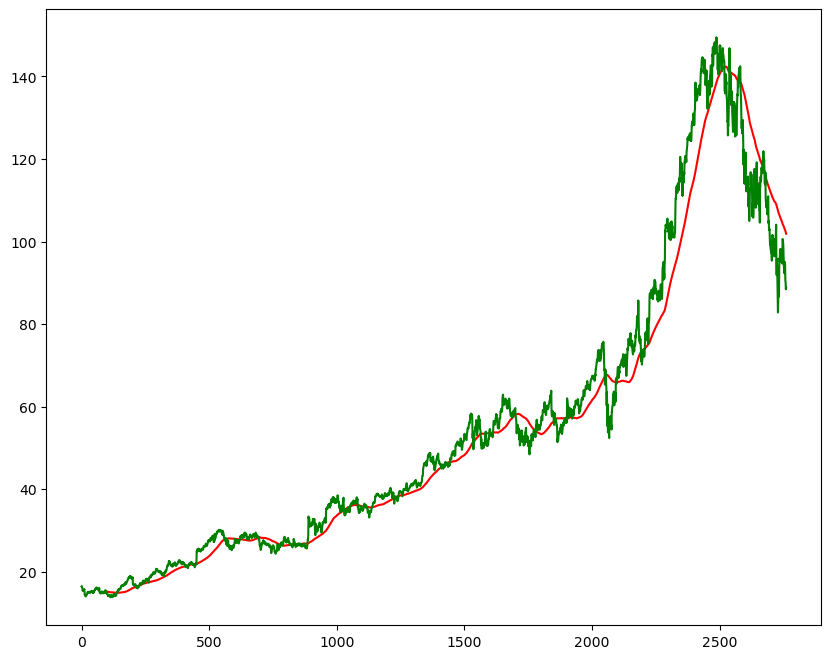

In [9]:
plt.figure(figsize = (10,8))
plt.plot(hundred_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [10]:
Two_hundred_days = data.Close.rolling(200).mean()
Two_hundred_days


Ticker,GOOG
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2756,111.496583
2757,111.280599
2758,111.065128
2759,110.852017


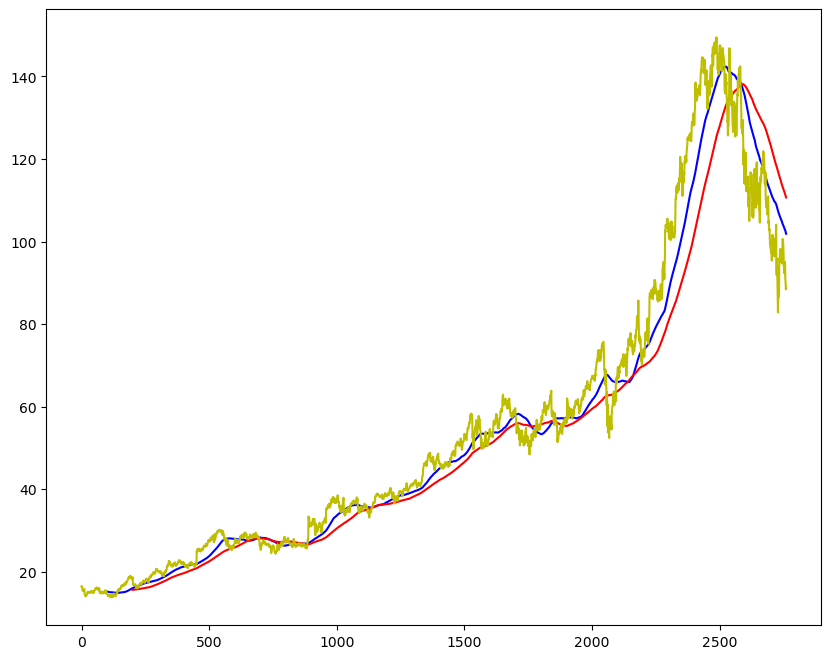

In [15]:
plt.figure(figsize = (10,8))
plt.plot(hundred_days,'b')
plt.plot(Two_hundred_days,'r')
plt.plot(data.Close,'y')
plt.show()

In [16]:
data.dropna(inplace = True)

In [17]:
data_train = pd.DataFrame(data.Close[0: int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[ int(len(data)*0.80) : len(data)])
data.shape[0]

2761

In [18]:
data_train.shape[0]

2208

In [19]:
data_test.shape[0]

553

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [21]:
data_train_scale = scaler.fit_transform(data_train)
data_train_scale

array([[0.03654398],
       [0.03753013],
       [0.034345  ],
       ...,
       [0.81515384],
       [0.83283884],
       [0.85304166]], shape=(2208, 1))

In [22]:
x = []
y = []

for i in range(100, data_train_scale.shape[0]):
    x.append(data_train_scale[i-100:i])
    y.append(data_train_scale[i,0])

In [23]:
x, y = np.array(x), np.array(y)

from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

model = Sequential()

model.add(LSTM(
    units=50,
    activation='relu',
    return_sequences=True,
    input_shape=(x.shape[1], 1)
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=60,
    activation='relu',
    return_sequences=True
))
model.add(Dropout(0.3))

model.add(LSTM(
    units=80,
    activation='relu',
    return_sequences=True
))
model.add(Dropout(0.4))

model.add(LSTM(
    units=120,
    activation='relu'
))

# OUTPUT LAYER
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.fit(
    x,
    y,
    epochs=10,
    batch_size=32,
    verbose=1
)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 335ms/step - loss: 0.0204
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 280ms/step - loss: 0.0020
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 281ms/step - loss: 0.0018
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 303ms/step - loss: 0.0018
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 353ms/step - loss: 0.0015
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - loss: 0.0014
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 319ms/step - loss: 0.0014
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 394ms/step - loss: 0.0014
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 301ms/step - loss: 0.0013
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 270ms/step - loss: 0.0011


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [27]:
hundred_days = data_train.tail(100)
data_test = pd.concat([hundred_days,data_test],ignore_index=True)

In [28]:
data_test

Ticker,GOOG
0,69.763237
1,69.568832
2,69.946747
3,70.274048
4,70.314713
...,...
648,94.533882
649,90.457352
650,90.120117
651,88.424049


In [29]:
data_test_scale = scaler.fit_transform(data_test)
data_test_scale

array([[0.02830225],
       [0.02593264],
       [0.03053908],
       [0.03452858],
       [0.03502425],
       [0.03435338],
       [0.04172197],
       [0.04347522],
       [0.04794839],
       [0.04623179],
       [0.03160285],
       [0.04744659],
       [0.05241562],
       [0.05818841],
       [0.0640462 ],
       [0.02656156],
       [0.03220751],
       [0.03623933],
       [0.05006423],
       [0.05514188],
       [0.04597763],
       [0.04341468],
       [0.05558918],
       [0.06317548],
       [0.04356579],
       [0.04922392],
       [0.        ],
       [0.02119954],
       [0.03246734],
       [0.04723502],
       [0.06335087],
       [0.08209021],
       [0.07573099],
       [0.08227146],
       [0.09133285],
       [0.10992088],
       [0.09154432],
       [0.09713   ],
       [0.09293469],
       [0.09557037],
       [0.09408933],
       [0.12441665],
       [0.12000373],
       [0.12609103],
       [0.09416772],
       [0.09186459],
       [0.10294501],
       [0.084

In [30]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])

In [31]:
x, y = np.array(x), np.array(y)


In [32]:
y_predict = model.predict(x)

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step


In [33]:
scaler.scale_

array([0.01218911])

In [34]:
y_predict

array([[0.08927227],
       [0.08668383],
       [0.08475269],
       [0.08358087],
       [0.08316699],
       [0.08343338],
       [0.08427034],
       [0.08556767],
       [0.08725492],
       [0.08930611],
       [0.09174685],
       [0.0945446 ],
       [0.09765052],
       [0.10090158],
       [0.10415628],
       [0.10737056],
       [0.11054616],
       [0.11373823],
       [0.11716673],
       [0.12104039],
       [0.1254748 ],
       [0.13053155],
       [0.13618168],
       [0.1423393 ],
       [0.14887702],
       [0.1556926 ],
       [0.16268739],
       [0.16974865],
       [0.17671658],
       [0.18345794],
       [0.18983378],
       [0.19571397],
       [0.20105468],
       [0.20586376],
       [0.21020849],
       [0.21412194],
       [0.21768026],
       [0.22101313],
       [0.22424595],
       [0.22747569],
       [0.23074687],
       [0.23406287],
       [0.23734286],
       [0.2404675 ],
       [0.24333444],
       [0.24583617],
       [0.24790268],
       [0.249

In [35]:
print('scale:',scaler.scale_)

scale: [0.01218911]


In [36]:
scale =1/scaler.scale_

In [37]:
scale

array([82.04045868])

In [38]:
y_predict = y_predict*scale

In [39]:
y_predict

array([[ 7.32393782],
       [ 7.11158135],
       [ 6.95314987],
       [ 6.85701323],
       [ 6.82305774],
       [ 6.84491295],
       [ 6.913577  ],
       [ 7.02001074],
       [ 7.15843359],
       [ 7.32671412],
       [ 7.5269538 ],
       [ 7.75648271],
       [ 8.01129349],
       [ 8.27801202],
       [ 8.54502883],
       [ 8.80872961],
       [ 9.06925802],
       [ 9.33113667],
       [ 9.61241209],
       [ 9.93020903],
       [10.29400979],
       [10.70886819],
       [11.17240768],
       [11.6775818 ],
       [12.21393939],
       [12.7730929 ],
       [13.34694818],
       [13.92625702],
       [14.49790936],
       [15.05097361],
       [15.57404999],
       [16.05646363],
       [16.49461795],
       [16.88915721],
       [17.24560098],
       [17.56666199],
       [17.85858842],
       [18.13201846],
       [18.39724064],
       [18.66220977],
       [18.93057867],
       [19.20262484],
       [19.47171745],
       [19.7280643 ],
       [19.96326927],
       [20

In [40]:
y = y*scale
y

array([10.37730408, 10.5027771 , 10.32424164,  9.88037872, 10.56874084,
        8.66436005,  9.72169495, 11.5754776 , 12.66750336, 13.94055176,
       11.4336319 , 12.11849976,  7.77219391, 10.28259277, 12.94918823,
       13.19815826, 14.39729309, 19.30302429, 20.00923157, 19.92889404,
       19.9908905 , 18.86959076, 19.48056793, 19.33823395, 20.68616486,
       20.90239716, 20.34546661, 19.18647766, 20.03651428, 18.95884705,
       18.59534454, 20.28249359, 20.40895081, 21.48809052, 19.87879944,
       21.73158264, 23.21194458, 23.15341187, 23.21391296, 22.79188538,
       22.74575806, 21.03876495, 20.60235596, 20.92173767, 19.84506226,
       20.22743988, 19.9908905 , 19.24202728, 18.40439606, 18.81899261,
       18.03196716, 18.47234344, 18.79321289, 20.64004517, 19.77861786,
       18.8264389 , 19.43940735, 18.26703644, 18.89587402, 18.61666107,
       21.19350433, 22.18338013, 20.17537689, 19.17508698, 19.56437683,
       18.85916901, 18.66130829, 21.37252808, 26.13542938, 26.35

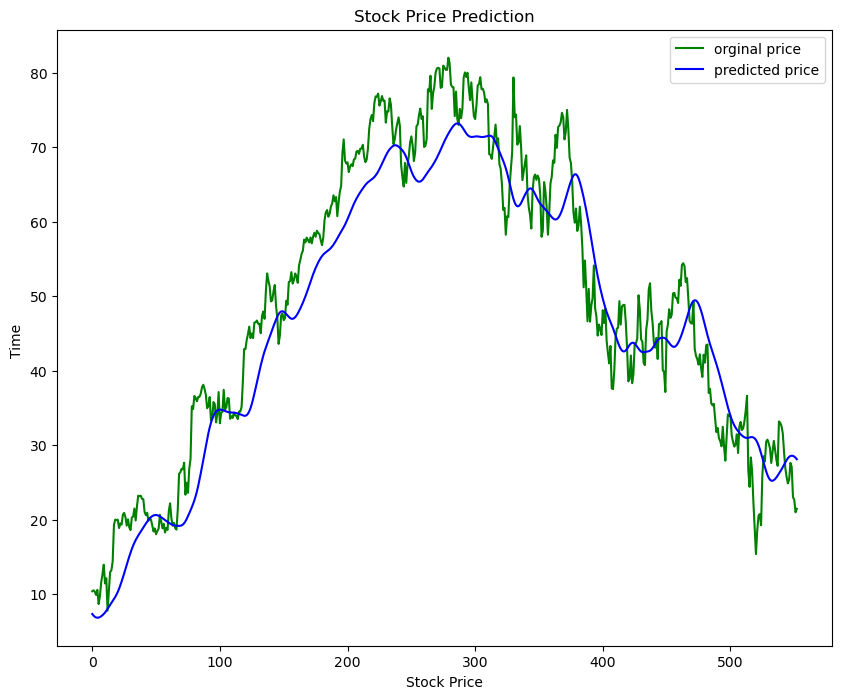

In [52]:
plt.figure(figsize = (10,8))
plt.plot(y,'g',label = 'orginal price' )
plt.plot(y_predict,'b',label = 'predicted price')
plt.xlabel('Stock Price')
plt.ylabel('Time ')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()


In [53]:
model.save('Stock Prediction.keras')